In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA: 12.4
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


In [3]:
import torch
import time

device = torch.device("cuda")

x = torch.randn(3000, 3000, device=device)
y = torch.randn(3000, 3000, device=device)

torch.cuda.synchronize()

start = time.perf_counter()

z = x @ y

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print(f"Device: {z.device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Matrix multiplication time: {elapsed:.4f} seconds")

Device: cuda:0
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU
Matrix multiplication time: 0.0614 seconds


In [5]:
import stim

circuit = stim.Circuit()

circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("CNOT", [1, 2])

print(circuit)

H 0
CX 0 1 1 2


In [6]:
import stim

circuit = stim.Circuit()

circuit.append("H", [0])
circuit.append("CX", [0, 1])
circuit.append("CX", [1, 2])

# Introduce a bit-flip error on qubit 1
circuit.append("X", [1])

print(circuit)

H 0
CX 0 1 1 2
X 1


In [7]:
import stim

circuit = stim.Circuit()

# Prepare |000>
# Introduce an X error on qubit 1
circuit.append("X", [1])

# Measure stabilizer Z0 Z1
circuit.append("M", [0, 1])

print(circuit)

X 1
M 0 1


In [8]:
import stim

circuit = stim.Circuit("""
    R 0 1 2

    X_ERROR(0.1) 0 1 2

    M 0 1 2
""")

print(circuit)

R 0 1 2
X_ERROR(0.1) 0 1 2
M 0 1 2


In [9]:
sampler = circuit.compile_sampler()

samples = sampler.sample(shots=20)

print(samples.astype(int))

[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [1 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 1 0]
 [0 0 0]
 [0 0 1]]


In [10]:
import stim

circuit = stim.Circuit("""
    # Data qubits: 0, 1, 2
    # Ancillas:    3, 4

    R 0 1 2 3 4

    # X error on middle data qubit
    X 1

    # Measure Z0 Z1 using ancilla 3
    CX 0 3
    CX 1 3

    # Measure Z1 Z2 using ancilla 4
    CX 1 4
    CX 2 4

    # Measure ancillas
    M 3 4
""")

print(circuit)

R 0 1 2 3 4
X 1
CX 0 3 1 3 1 4 2 4
M 3 4


In [11]:
sampler = circuit.compile_sampler()

samples = sampler.sample(shots=10)

print(samples.astype(int))

[[1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]]


In [12]:
import stim

def repetition_circuit(error_qubit=None):
    circuit = stim.Circuit()

    circuit.append("R", [0, 1, 2, 3, 4])

    if error_qubit is not None:
        circuit.append("X", [error_qubit])

    # Z0 Z1
    circuit.append("CX", [0, 3])
    circuit.append("CX", [1, 3])

    # Z1 Z2
    circuit.append("CX", [1, 4])
    circuit.append("CX", [2, 4])

    # Measure stabilizer ancillas
    circuit.append("M", [3, 4])

    return circuit

In [13]:
for error in [None, 0, 1, 2]:
    circuit = repetition_circuit(error)

    sampler = circuit.compile_sampler()
    syndrome = sampler.sample(shots=1)

    print(f"Error: {error}, Syndrome: {syndrome.astype(int)[0]}")

Error: None, Syndrome: [0 0]
Error: 0, Syndrome: [1 0]
Error: 1, Syndrome: [1 1]
Error: 2, Syndrome: [0 1]


In [18]:
def noisy_repetition_circuit(p=0.3):
    circuit = stim.Circuit()

    circuit.append("R", [0, 1, 2, 3, 4])

    # Independent X noise on data qubits
    circuit.append("X_ERROR", [0, 1, 2], p)

    # Z0 Z1
    circuit.append("CX", [0, 3])
    circuit.append("CX", [1, 3])

    # Z1 Z2
    circuit.append("CX", [1, 4])
    circuit.append("CX", [2, 4])

    # Measure stabilizer ancillas
    circuit.append("M", [3, 4])

    return circuit

In [19]:
circuit = noisy_repetition_circuit(p=0.1)

sampler = circuit.compile_sampler()

samples = sampler.sample(shots=20)

print(samples.astype(int))

[[1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]]


In [16]:
for error in [None, 0, 1, 2]:
    circuit = repetition_circuit(error)
    sampler = circuit.compile_sampler()
    syndrome = sampler.sample(shots=1)
    print(f"Error: {error}, Syndrome: {syndrome.astype(int)[0]}")

Error: None, Syndrome: [0 0]
Error: 0, Syndrome: [1 0]
Error: 1, Syndrome: [1 1]
Error: 2, Syndrome: [0 1]


In [20]:
circuit = noisy_repetition_circuit(p=0.1)

sampler = circuit.compile_sampler()

samples = sampler.sample(shots=20)

print(samples.astype(int))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


In [ ]:
# distance 3 surface code 

In [21]:
import stim

distance = 3
rounds = 3

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    distance=distance,
    rounds=rounds,
)

print(circuit)

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
RX 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
TICK
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
TICK
MR 2 9 11 13 14 16 18 25
DETECTOR(2, 0, 0) rec[-8]
DETECTOR(2, 4, 0) rec[-3]
DETECTOR(4, 2, 0) rec[-6]
DETECTOR(4, 6, 0) rec[-1]
REPEAT 2 {
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 

In [22]:
print(circuit.diagram("timeline-text"))

      /------------------\     /---\ /---\ /-----\   /---------------------------------\ /REP 2       /---\ /---\ /-----\   /------------------------------------------------------------------------------\ \ /--------------------------------------------------------------------------------------------------------\
 q0: ------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------
                                                                                         |                                                                                                                   |
 q1: -QUBIT_COORDS(1,1)-RX-----X---------------@-----------------------------------------|------------X---------------@---------------------------------------------

In [23]:
print("Number of qubits:", circuit.num_qubits)

Number of qubits: 26


In [24]:
print("Number of detectors:", circuit.num_detectors)
print("Number of observables:", circuit.num_observables)

Number of detectors: 24
Number of observables: 1


In [25]:
sampler = circuit.compile_detector_sampler()

detection_events, observables = sampler.sample(
    shots=1,
    separate_observables=True,
)

print("Detection events:")
print(detection_events.astype(int))

print("\nLogical observable:")
print(observables.astype(int))

Detection events:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Logical observable:
[[0]]


In [26]:
p = 0.01

noisy_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    distance=3,
    rounds=3,
    after_clifford_depolarization=p,
    before_round_data_depolarization=p,
    before_measure_flip_probability=p,
    after_reset_flip_probability=p,
)

print(noisy_circuit)

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
RX 1 3 5 8 10 12 15 17 19
Z_ERROR(0.01) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.01) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.01) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.01) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.01) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.01) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.01) 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE2(0.01) 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
DEPOLARIZE1(0.01) 2 11 16 25
TICK
X_ERROR(0

In [27]:
sampler = noisy_circuit.compile_detector_sampler()

syndromes, observables = sampler.sample(
    shots=20,
    separate_observables=True,
)

print("Syndrome shape:", syndromes.shape)
print("Observable shape:", observables.shape)

print("\nFirst 20 syndromes:")
print(syndromes.astype(int))

print("\nLogical outcomes:")
print(observables.astype(int))

Syndrome shape: (20, 24)
Observable shape: (20, 1)

First 20 syndromes:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 

In [30]:
# how often does the code fail?
import numpy as np

num_shots = 10_000

syndromes, actual_observables = noisy_circuit.compile_detector_sampler().sample(
    shots=num_shots,
    separate_observables=True,
)

logical_error_rate_without_decoder = np.mean(actual_observables[:, 0])

print("Shots:", num_shots)
print("Logical error rate:", logical_error_rate_without_decoder)

Shots: 10000
Logical error rate: 0.1911


In [31]:
dem = noisy_circuit.detector_error_model(
    decompose_errors=True
)

print(dem)

error(0.01911873511075361937) D0 D2
error(0.03501987560309133274) D0 D4
error(0.01911873511075361937) D0 L0
error(0.02169031111111104082) D1 D2
error(0.005333333333333313206) D1 D2 ^ D5
error(0.01911873511075361937) D1 D3
error(0.001338700097173320998) D1 D4
error(0.001338700097173320998) D1 D4 ^ D5
error(0.002006705456917235505) D1 D6
error(0.002006705456917235505) D1 D6 ^ D5
error(0.0006697986788568588423) D1 D6 ^ D5 ^ D8
error(0.0006697986788568588423) D1 D6 ^ D8
error(0.0356427617491228213) D1 D9
error(0.0006697986788568588423) D1 D9 ^ D5
error(0.0006697986788568588423) D1 D9 ^ D5 ^ D8
error(0.0006697986788568588423) D1 D9 ^ D8
error(0.04059590562379881973) D1 L0
error(0.0006697986788568588423) D1 L0 ^ D4 L0
error(0.0006697986788568588423) D1 L0 ^ D4 L0 ^ D5
error(0.0006697986788568588423) D1 L0 ^ D4 L0 ^ D5 ^ D8
error(0.0006697986788568588423) D1 L0 ^ D4 L0 ^ D8
error(0.0006697986788568588423) D1 L0 ^ D5
error(0.0006697986788568588423) D1 L0 ^ D5 ^ D8
error(0.005995987492949031786

In [32]:
import pymatching

matching = pymatching.Matching.from_detector_error_model(dem)

print(matching)

<pymatching.Matching object with 24 detectors, 0 boundary nodes, and 78 edges>


In [33]:
predicted_observables = matching.decode_batch(syndromes)

print("Predicted shape:", predicted_observables.shape)
print("Actual shape:", actual_observables.shape)

Predicted shape: (10000, 1)
Actual shape: (10000, 1)


In [34]:
logical_failures = np.any(
    predicted_observables != actual_observables,
    axis=1
)

logical_error_rate = np.mean(logical_failures)

print("Shots:", num_shots)
print("Logical failures:", np.sum(logical_failures))
print("Decoded logical error rate:", logical_error_rate)

Shots: 10000
Logical failures: 684
Decoded logical error rate: 0.0684


In [35]:
import numpy as np
import stim
import pymatching

dist = 3
rounds = 3
shots = 10000

physical_error_rates = [
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.03,
]

In [36]:
results = []

for p in physical_error_rates:

    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",
        distance=dist,
        rounds=rounds,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )

    sampler = circuit.compile_detector_sampler()

    syndromes, actual_observables = sampler.sample(
        shots=shots,
        separate_observables=True,
    )

    dem = circuit.detector_error_model(
        decompose_errors=True
    )

    matching = pymatching.Matching.from_detector_error_model(dem)

    predicted_observables = matching.decode_batch(syndromes)

    logical_failures = np.any(
        predicted_observables != actual_observables,
        axis=1
    )

    logical_error_rate = np.mean(logical_failures)

    results.append(logical_error_rate)

    print(
        f"p={p:.3f} | "
        f"logical error rate={logical_error_rate:.5f}"
    )

p=0.001 | logical error rate=0.00090
p=0.002 | logical error rate=0.00410
p=0.005 | logical error rate=0.01950
p=0.010 | logical error rate=0.06910
p=0.020 | logical error rate=0.18880
p=0.030 | logical error rate=0.29400


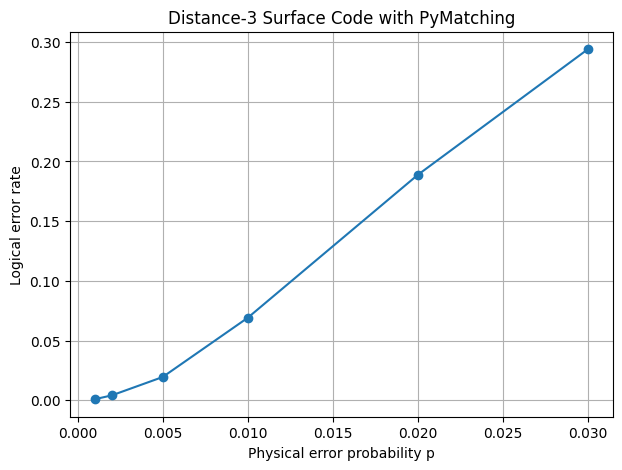

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    physical_error_rates,
    results,
    marker="o"
)

plt.xlabel("Physical error probability p")
plt.ylabel("Logical error rate")
plt.title("Distance-3 Surface Code with PyMatching")

plt.grid(True)
plt.show()

In [39]:
# d=3,5,7
import stim
import pymatching
import numpy as np

distances = [3, 5, 7]
p = 0.005
shots = 10000

distance_results = {}

for d in distances:

    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )

    sampler = circuit.compile_detector_sampler()

    syndromes, actual_observables = sampler.sample(
        shots=shots,
        separate_observables=True,
    )

    dem = circuit.detector_error_model(
        decompose_errors=True
    )

    matching = pymatching.Matching.from_detector_error_model(dem)

    predicted_observables = matching.decode_batch(syndromes)

    logical_failures = np.any(
        predicted_observables != actual_observables,
        axis=1,
    )

    logical_error_rate = np.mean(logical_failures)

    distance_results[d] = logical_error_rate

    print(
        f"d={d} | "
        f"detectors={circuit.num_detectors} | "
        f"shots={shots} | "
        f"logical error rate={logical_error_rate:.6f}"
    )

d=3 | detectors=24 | shots=10000 | logical error rate=0.018800
d=5 | detectors=120 | shots=10000 | logical error rate=0.016000
d=7 | detectors=336 | shots=10000 | logical error rate=0.013100


In [40]:
coords = circuit.get_detector_coordinates()

print("Number of detector coordinates:", len(coords))

for detector_id, coord in list(coords.items())[:20]:
    print(detector_id, coord)

Number of detector coordinates: 336
0 [2.0, 0.0, 0.0]
1 [2.0, 4.0, 0.0]
2 [2.0, 8.0, 0.0]
3 [2.0, 12.0, 0.0]
4 [4.0, 2.0, 0.0]
5 [4.0, 6.0, 0.0]
6 [4.0, 10.0, 0.0]
7 [4.0, 14.0, 0.0]
8 [6.0, 0.0, 0.0]
9 [6.0, 4.0, 0.0]
10 [6.0, 8.0, 0.0]
11 [6.0, 12.0, 0.0]
12 [8.0, 2.0, 0.0]
13 [8.0, 6.0, 0.0]
14 [8.0, 10.0, 0.0]
15 [8.0, 14.0, 0.0]
16 [10.0, 0.0, 0.0]
17 [10.0, 4.0, 0.0]
18 [10.0, 8.0, 0.0]
19 [10.0, 12.0, 0.0]


In [42]:
# visualize one syndrome For the d=3 circuit:

distance = 3
rounds = 3
p = 0.01

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    distance=distance,
    rounds=rounds,
    after_clifford_depolarization=p,
    before_round_data_depolarization=p,
    before_measure_flip_probability=p,
    after_reset_flip_probability=p,
)

sampler = circuit.compile_detector_sampler()

syndromes, observables = sampler.sample(
    shots=100,
    separate_observables=True,
)

coords = circuit.get_detector_coordinates()

print("Detector coordinates:")
for i, coord in coords.items():
    print(f"D{i}: {coord}")

Detector coordinates:
D0: [2.0, 0.0, 0.0]
D1: [2.0, 4.0, 0.0]
D2: [4.0, 2.0, 0.0]
D3: [4.0, 6.0, 0.0]
D4: [2.0, 0.0, 1.0]
D5: [2.0, 2.0, 1.0]
D6: [4.0, 2.0, 1.0]
D7: [6.0, 2.0, 1.0]
D8: [0.0, 4.0, 1.0]
D9: [2.0, 4.0, 1.0]
D10: [4.0, 4.0, 1.0]
D11: [4.0, 6.0, 1.0]
D12: [2.0, 0.0, 2.0]
D13: [2.0, 2.0, 2.0]
D14: [4.0, 2.0, 2.0]
D15: [6.0, 2.0, 2.0]
D16: [0.0, 4.0, 2.0]
D17: [2.0, 4.0, 2.0]
D18: [4.0, 4.0, 2.0]
D19: [4.0, 6.0, 2.0]
D20: [2.0, 0.0, 3.0]
D21: [2.0, 4.0, 3.0]
D22: [4.0, 2.0, 3.0]
D23: [4.0, 6.0, 3.0]


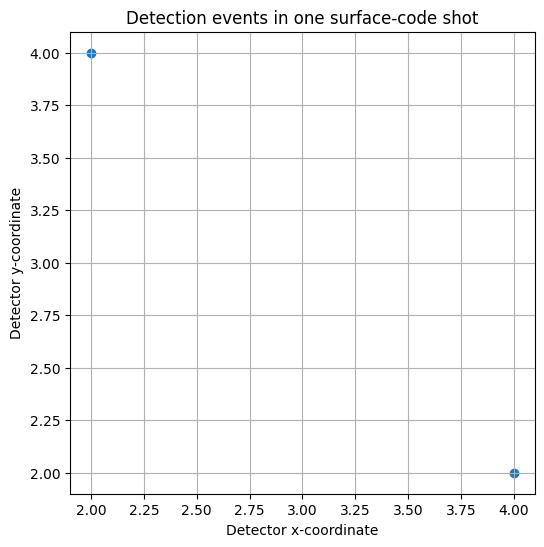

In [43]:
import matplotlib.pyplot as plt
import numpy as np

shot = syndromes[0]

xs = []
ys = []

for detector_id, coord in coords.items():
    if shot[detector_id]:
        xs.append(coord[0])
        ys.append(coord[1])

plt.figure(figsize=(6, 6))

plt.scatter(xs, ys)

plt.xlabel("Detector x-coordinate")
plt.ylabel("Detector y-coordinate")
plt.title("Detection events in one surface-code shot")

plt.grid(True)
plt.show()

In [ ]:
# dataset generation

In [44]:
import stim
import numpy as np

distance = 3
rounds = 3
p = 0.01
shots = 100_000

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    distance=distance,
    rounds=rounds,
    after_clifford_depolarization=p,
    before_round_data_depolarization=p,
    before_measure_flip_probability=p,
    after_reset_flip_probability=p,
)

sampler = circuit.compile_detector_sampler()

X, y = sampler.sample(
    shots=shots,
    separate_observables=True,
)

y = y[:, 0].astype(np.int8)
X = X.astype(np.int8)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Logical 0:", np.sum(y == 0))
print("Logical 1:", np.sum(y == 1))

X shape: (100000, 24)
y shape: (100000,)
Logical 0: 81303
Logical 1: 18697


In [45]:
np.savez_compressed(
    "qec_surface_d3_p001_dataset.npz",
    X=X,
    y=y,
)

print("Dataset saved.")

Dataset saved.


In [46]:
import numpy as np

X = np.load("qec_surface_d3_p001_dataset.npz")["X"]
y = np.load("qec_surface_d3_p001_dataset.npz")["y"]

majority_class = np.bincount(y).argmax()

baseline_predictions = np.full_like(
    y,
    majority_class
)

baseline_accuracy = np.mean(
    baseline_predictions == y
)

print("Majority class:", majority_class)
print("Baseline accuracy:", baseline_accuracy)

Majority class: 0
Baseline accuracy: 0.81303


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print()
print("Train positive rate:", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Training: (80000, 24) (80000,)
Validation: (10000, 24) (10000,)
Test: (10000, 24) (10000,)

Train positive rate: 0.186975
Validation positive rate: 0.1869
Test positive rate: 0.187


In [49]:
# linear ML baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Balanced accuracy:",
      balanced_accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1:",
      f1_score(y_test, y_pred))

print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8063
Balanced accuracy: 0.5360258763015437
Precision: 0.42669584245076586
Recall: 0.10427807486631016
F1: 0.16759776536312848

Confusion matrix:
[[7868  262]
 [1675  195]]


In [ ]:
# MLP stage 1

In [51]:
# ============================================================
# QEC ML STAGE 1
# Surface Code d=3
# Syndrome -> Logical Observable
# MLP baseline
# ============================================================

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# ============================================================
# 1. Configuration
# ============================================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. Load dataset
# ============================================================

DATASET_PATH = "qec_surface_d3_p001_dataset.npz"

data = np.load(DATASET_PATH)

X = data["X"]
y = data["y"]

print()
print("Dataset")
print("X shape:", X.shape)
print("y shape:", y.shape)

print()
print("Class distribution:")
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))
print("Positive rate:", np.mean(y))


# ============================================================
# 3. Train / validation / test split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print()
print("Splits:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ============================================================
# 4. Convert to PyTorch tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32,
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32,
).unsqueeze(1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32,
).unsqueeze(1)


# ============================================================
# 5. DataLoaders
# ============================================================

BATCH_SIZE = 1024

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 6. Define MLP
# ============================================================

class QECMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):

        return self.network(x)


model = QECMLP(
    input_dim=X_train.shape[1]
).to(DEVICE)

print()
print("Model:")
print(model)


# ============================================================
# 7. Calculate class weight
# ============================================================

num_class_0 = np.sum(y_train == 0)
num_class_1 = np.sum(y_train == 1)

pos_weight = num_class_0 / num_class_1

print()
print("Positive class weight:", pos_weight)


# ============================================================
# 8. Loss function
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [pos_weight],
        dtype=torch.float32,
        device=DEVICE,
    )
)


# ============================================================
# 9. Optimizer
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)


# ============================================================
# 10. Evaluation function
# ============================================================

def evaluate(model, loader):

    model.eval()

    all_probabilities = []
    all_targets = []

    with torch.no_grad():

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(batch_X)

            probabilities = torch.sigmoid(
                logits
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

            all_targets.append(
                batch_y.numpy()
            )

    probabilities = np.concatenate(
        all_probabilities
    ).ravel()

    targets = np.concatenate(
        all_targets
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(np.int8)

    return targets, probabilities, predictions


# ============================================================
# 11. Training
# ============================================================

EPOCHS = 30

best_val_f1 = -1.0
best_state = None

print()
print("Training...")

for epoch in range(1, EPOCHS + 1):

    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(
            DEVICE,
            non_blocking=True,
        )

        batch_y = batch_y.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(batch_X)

        loss = criterion(
            logits,
            batch_y,
        )

        loss.backward()

        optimizer.step()

        batch_size = batch_X.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    train_loss = (
        total_loss / total_samples
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_targets, val_probs, val_predictions = evaluate(
        model,
        val_loader,
    )

    val_f1 = f1_score(
        val_targets,
        val_predictions,
        zero_division=0,
    )

    val_balanced_accuracy = balanced_accuracy_score(
        val_targets,
        val_predictions,
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss={train_loss:.5f} | "
        f"Val Balanced Acc="
        f"{val_balanced_accuracy:.5f} | "
        f"Val F1="
        f"{val_f1:.5f}"
    )

    # --------------------------------------------------------
    # Save best model according to validation F1
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }


# ============================================================
# 12. Restore best model
# ============================================================

model.load_state_dict(
    best_state
)

model.to(DEVICE)


# ============================================================
# 13. Final test evaluation
# ============================================================

test_targets, test_probs, test_predictions = evaluate(
    model,
    test_loader,
)

accuracy = accuracy_score(
    test_targets,
    test_predictions,
)

balanced_accuracy = balanced_accuracy_score(
    test_targets,
    test_predictions,
)

precision = precision_score(
    test_targets,
    test_predictions,
    zero_division=0,
)

recall = recall_score(
    test_targets,
    test_predictions,
    zero_division=0,
)

f1 = f1_score(
    test_targets,
    test_predictions,
    zero_division=0,
)

cm = confusion_matrix(
    test_targets,
    test_predictions,
)


# ============================================================
# 14. Results
# ============================================================

print()
print("=" * 60)
print("FINAL MLP RESULTS")
print("=" * 60)

print(f"Accuracy:           {accuracy:.6f}")
print(f"Balanced accuracy:  {balanced_accuracy:.6f}")
print(f"Precision:          {precision:.6f}")
print(f"Recall:             {recall:.6f}")
print(f"F1:                 {f1:.6f}")

print()
print("Confusion matrix:")
print(cm)

print()
print("Predicted class distribution:")
print(
    "Predicted 0:",
    np.sum(test_predictions == 0),
)

print(
    "Predicted 1:",
    np.sum(test_predictions == 1),
)

Device: cuda
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU

Dataset
X shape: (100000, 24)
y shape: (100000,)

Class distribution:
Class 0: 81303
Class 1: 18697
Positive rate: 0.18697

Splits:
Train: (80000, 24)
Validation: (10000, 24)
Test: (10000, 24)

Model:
QECMLP(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Positive class weight: 4.348308597406071

Training...
Epoch 01/30 | Loss=1.05091 | Val Balanced Acc=0.72584 | Val F1=0.48113
Epoch 02/30 | Loss=0.83991 | Val Balanced Acc=0.78491 | Val F1=0.54167
Epoch 03/30 | Loss=0.67712 | Val Balanced Acc=0.83895 | Val F1=0.62982
Epoch 04/30 | Loss=0.58606 | Val Balanced Acc=0.85676 | Val F1=0.66640
Epoch 05/30 | Loss=0.54417 | Val Balanced Acc=0.86803 | Val F1=0.68544
Epoch 06/30 | Loss=0.51834 | Val Balanced Acc=0.87096 | Val F1=0.70069
Epoch 07/30 

In [54]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": X_train.shape[1],
        "seed": SEED,
        "positive_class_weight": pos_weight,
        "best_val_f1": best_val_f1,
    },
    "qec_mlp_d3_p001.pt",
)

print("Model saved.")

Model saved.


In [60]:
# dataset generation for p=0.005,0.010.0.020

# ============================================================
# QEC DATASET GENERATOR
# Surface code d=3
# Detector syndrome -> logical observable
# ============================================================

import numpy as np
import stim


# ============================================================
# Configuration
# ============================================================

DISTANCE = 3
SHOTS = 50_000

ERROR_RATES = [
    0.005,
    0.010,
    0.020,
]

SEED = 42


# ============================================================
# Build surface-code circuit
# ============================================================

def build_surface_code_circuit(p):

    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",
        distance=DISTANCE,
        rounds=DISTANCE,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )

    return circuit


# ============================================================
# Generate dataset
# ============================================================

def generate_dataset(p, shots=100_000):

    print()
    print("=" * 60)
    print(f"Generating dataset: d={DISTANCE}, p={p}")
    print("=" * 60)

    circuit = build_surface_code_circuit(p)

    print("Number of detectors:",
          circuit.num_detectors)

    print("Number of observables:",
          circuit.num_observables)

    # --------------------------------------------------------
    # Detector sampler
    # --------------------------------------------------------

    sampler = circuit.compile_detector_sampler(
        seed=SEED
    )

    samples, observables = sampler.sample(
        shots=shots,
        separate_observables=True,
    )

    X = samples.astype(np.float32)

    y = observables[:, 0].astype(np.float32)

    print()
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    print()
    print("Class distribution:")

    print(
        "Logical 0:",
        np.sum(y == 0)
    )

    print(
        "Logical 1:",
        np.sum(y == 1)
    )

    print(
        "Logical error rate:",
        np.mean(y)
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = (
        f"qec_surface_d{DISTANCE}"
        f"_p{int(p * 1000):03d}.npz"
    )

    np.savez_compressed(
        filename,
        X=X,
        y=y,
        distance=DISTANCE,
        physical_error_rate=p,
    )

    print()
    print("Saved:", filename)

    return X, y


# ============================================================
# Generate all datasets
# ============================================================

datasets = {}

for p in ERROR_RATES:

    X, y = generate_dataset(
        p,
        shots=SHOTS,
    )

    datasets[p] = {
        "X": X,
        "y": y,
    }


Generating dataset: d=3, p=0.005
Number of detectors: 24
Number of observables: 1

X shape: (50000, 24)
y shape: (50000,)

Class distribution:
Logical 0: 44810
Logical 1: 5190
Logical error rate: 0.1038

Saved: qec_surface_d3_p005.npz

Generating dataset: d=3, p=0.01
Number of detectors: 24
Number of observables: 1

X shape: (50000, 24)
y shape: (50000,)

Class distribution:
Logical 0: 40588
Logical 1: 9412
Logical error rate: 0.18824

Saved: qec_surface_d3_p010.npz

Generating dataset: d=3, p=0.02
Number of detectors: 24
Number of observables: 1

X shape: (50000, 24)
y shape: (50000,)

Class distribution:
Logical 0: 34731
Logical 1: 15269
Logical error rate: 0.30538

Saved: qec_surface_d3_p020.npz


In [56]:
# ============================================================
# Verify generated datasets
# ============================================================

for p, data in datasets.items():

    X = data["X"]
    y = data["y"]

    print(
        f"p={p:.3f} | "
        f"X={X.shape} | "
        f"y={y.shape} | "
        f"logical rate={y.mean():.6f}"
    )

p=0.005 | X=(100000, 24) | y=(100000,) | logical rate=0.103040
p=0.010 | X=(100000, 24) | y=(100000,) | logical rate=0.186850
p=0.020 | X=(100000, 24) | y=(100000,) | logical rate=0.305620


In [58]:
# using the model trained for p=0.010 first time

# ============================================================
# CROSS-NOISE GENERALIZATION TEST
# MLP trained at p=0.010
# ============================================================

import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# ============================================================
# Configuration
# ============================================================

MODEL_PATH = "qec_mlp_d3_p010.pt"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# Recreate model architecture
# ============================================================

class QECMLP(torch.nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = torch.nn.Sequential(

            torch.nn.Linear(
                input_dim,
                64
            ),

            torch.nn.ReLU(),

            torch.nn.Linear(
                64,
                32
            ),

            torch.nn.ReLU(),

            torch.nn.Linear(
                32,
                1
            ),
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# Load checkpoint
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)

input_dim = checkpoint["input_dim"]

model = QECMLP(
    input_dim=input_dim
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Model loaded.")
print("Device:", DEVICE)


# ============================================================
# Prediction function
# ============================================================

def predict_dataset(model, X):

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
    )

    probabilities = []

    batch_size = 4096

    with torch.no_grad():

        for start in range(
            0,
            len(X_tensor),
            batch_size,
        ):

            batch = X_tensor[
                start:start + batch_size
            ].to(DEVICE)

            logits = model(batch)

            probs = torch.sigmoid(
                logits
            )

            probabilities.append(
                probs.cpu().numpy()
            )

    probabilities = np.concatenate(
        probabilities
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(np.int8)

    return probabilities, predictions


# ============================================================
# Evaluate each noise level
# ============================================================

results = []

for p in [0.005, 0.010, 0.020]:

    filename = (
        f"qec_surface_d3"
        f"_p{int(p * 1000):03d}.npz"
    )

    data = np.load(filename)

    X = data["X"]
    y = data["y"].astype(np.int8)

    probabilities, predictions = (
        predict_dataset(
            model,
            X,
        )
    )

    accuracy = accuracy_score(
        y,
        predictions,
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y,
            predictions,
        )
    )

    precision = precision_score(
        y,
        predictions,
        zero_division=0,
    )

    recall = recall_score(
        y,
        predictions,
        zero_division=0,
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0,
    )

    cm = confusion_matrix(
        y,
        predictions,
    )

    results.append(
        {
            "p": p,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )

    print()
    print("=" * 60)
    print(f"TEST p={p:.3f}")
    print("=" * 60)

    print(
        f"Accuracy:          {accuracy:.6f}"
    )

    print(
        f"Balanced accuracy: {balanced_accuracy:.6f}"
    )

    print(
        f"Precision:         {precision:.6f}"
    )

    print(
        f"Recall:            {recall:.6f}"
    )

    print(
        f"F1:                {f1:.6f}"
    )

    print()
    print("Confusion matrix:")
    print(cm)

Model loaded.
Device: cuda

TEST p=0.005
Accuracy:          0.964790
Balanced accuracy: 0.954774
Precision:         0.768464
Recall:            0.942158
F1:                0.846493

Confusion matrix:
[[86771  2925]
 [  596  9708]]

TEST p=0.010
Accuracy:          0.894010
Balanced accuracy: 0.894225
Precision:         0.659525
Recall:            0.894568
F1:                0.759272

Confusion matrix:
[[72686  8629]
 [ 1970 16715]]

TEST p=0.020
Accuracy:          0.735710
Balanced accuracy: 0.763804
Precision:         0.543995
Recall:            0.836071
F1:                0.659126

Confusion matrix:
[[48019 21419]
 [ 5010 25552]]


In [59]:
# ============================================================
# Re-save checkpoint using plain Python types
# ============================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": int(input_dim),
        "seed": int(checkpoint["seed"]),
        "positive_class_weight": float(
            checkpoint["positive_class_weight"]
        ),
        "best_val_f1": float(
            checkpoint["best_val_f1"]
        ),
    },
    MODEL_PATH,
)

print("Checkpoint re-saved successfully.")

Checkpoint re-saved successfully.


In [61]:
# creating 50000 shots for p=0.005,0.010.0.020 and then combining them

import numpy as np

datasets = []

for p in [0.005, 0.010, 0.020]:

    filename = (
        f"qec_surface_d3"
        f"_p{int(p * 1000):03d}.npz"
    )

    data = np.load(filename)

    datasets.append(
        (
            data["X"],
            data["y"],
        )
    )

X_mixed = np.concatenate(
    [item[0] for item in datasets],
    axis=0,
)

y_mixed = np.concatenate(
    [item[1] for item in datasets],
    axis=0,
)

print("Mixed dataset:")
print("X:", X_mixed.shape)
print("y:", y_mixed.shape)

print()
print("Logical-1 fraction:", y_mixed.mean())

Mixed dataset:
X: (150000, 24)
y: (150000,)

Logical-1 fraction: 0.19914


In [63]:
# ============================================================
# QEC-ML DATASET GENERATOR
# Surface code d=3
#
# Generates independent train/test datasets for multiple
# physical noise rates.
#
# Dataset:
#   X = detector syndrome
#   y = logical observable
#
# ============================================================

import os
import numpy as np
import stim


# ============================================================
# Configuration
# ============================================================

DISTANCE = 3

TRAIN_SHOTS = 50_000
TEST_SHOTS = 100_000

NOISE_RATES = [0.005, 0.010, 0.020]

BASE_DIR = os.path.expanduser("~/Desktop/qskit/qec_ml")

TRAIN_DIR = os.path.join(
    BASE_DIR,
    "data",
    "train",
)

TEST_DIR = os.path.join(
    BASE_DIR,
    "data",
    "test",
)

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)


# ============================================================
# Reproducibility
# ============================================================

TRAIN_SEEDS = {
    0.005: 1005,
    0.010: 1010,
    0.020: 1020,
}

TEST_SEEDS = {
    0.005: 2005,
    0.010: 2010,
    0.020: 2020,
}


# ============================================================
# Build surface-code circuit
# ============================================================

def build_surface_code_circuit(
    distance,
    rounds,
    p,
):
    """
    Construct a rotated surface-code memory circuit.

    Noise model:
        - after Clifford depolarization
        - before-round data depolarization
        - measurement bit flips
        - reset bit flips

    Parameters
    ----------
    distance : int
        Surface-code distance.

    rounds : int
        Number of syndrome-measurement rounds.

    p : float
        Physical error probability.

    Returns
    -------
    stim.Circuit
    """

    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",

        distance=distance,
        rounds=rounds,

        after_clifford_depolarization=p,

        before_round_data_depolarization=p,

        before_measure_flip_probability=p,

        after_reset_flip_probability=p,
    )

    return circuit


# ============================================================
# Generate one dataset
# ============================================================

def generate_dataset(
    distance,
    shots,
    p,
    seed,
):
    """
    Generate detector syndrome and logical observable data.

    Returns
    -------
    X : np.ndarray
        Detector measurements.
        Shape = (shots, num_detectors)

    y : np.ndarray
        Logical observable.
        Shape = (shots,)

    circuit : stim.Circuit
        Circuit used to generate the data.
    """

    # --------------------------------------------------------
    # Build circuit
    # --------------------------------------------------------

    circuit = build_surface_code_circuit(
        distance=distance,
        rounds=distance,
        p=p,
    )

    # --------------------------------------------------------
    # Compile detector sampler
    # --------------------------------------------------------

    sampler = circuit.compile_detector_sampler(
        seed=seed
    )

    # --------------------------------------------------------
    # Sample detector outcomes and observables
    # --------------------------------------------------------

    samples, observables = sampler.sample(
        shots=shots,
        separate_observables=True,
    )

    # --------------------------------------------------------
    # Convert to ML format
    # --------------------------------------------------------

    X = samples.astype(
        np.float32
    )

    y = observables[:, 0].astype(
        np.int64
    )

    return X, y, circuit


# ============================================================
# Save dataset
# ============================================================

def save_dataset(
    path,
    X,
    y,
    distance,
    p,
    shots,
    seed,
):
    """
    Save dataset together with metadata.
    """

    np.savez_compressed(
        path,

        X=X,
        y=y,

        distance=np.int64(
            distance
        ),

        noise_rate=np.float64(
            p
        ),

        shots=np.int64(
            shots
        ),

        seed=np.int64(
            seed
        ),

        detector_count=np.int64(
            X.shape[1]
        ),

        logical_error_rate=np.float64(
            y.mean()
        ),
    )


# ============================================================
# Generate TRAINING DATA
# ============================================================

print("=" * 70)
print("GENERATING TRAINING DATA")
print("=" * 70)

for p in NOISE_RATES:

    seed = TRAIN_SEEDS[p]

    filename = (
        f"d{DISTANCE}_p{int(p * 1000):03d}.npz"
    )

    path = os.path.join(
        TRAIN_DIR,
        filename,
    )

    print()
    print(f"Noise rate : {p}")
    print(f"Shots      : {TRAIN_SHOTS}")
    print(f"Seed       : {seed}")
    print(f"Output     : {path}")

    X, y, circuit = generate_dataset(
        distance=DISTANCE,
        shots=TRAIN_SHOTS,
        p=p,
        seed=seed,
    )

    save_dataset(
        path=path,
        X=X,
        y=y,
        distance=DISTANCE,
        p=p,
        shots=TRAIN_SHOTS,
        seed=seed,
    )

    print(f"X shape    : {X.shape}")
    print(f"y shape    : {y.shape}")
    print(
        f"Logical-1 rate : {y.mean():.6f}"
    )


# ============================================================
# Generate TEST DATA
# ============================================================

print()
print("=" * 70)
print("GENERATING TEST DATA")
print("=" * 70)

for p in NOISE_RATES:

    seed = TEST_SEEDS[p]

    filename = (
        f"d{DISTANCE}_p{int(p * 1000):03d}.npz"
    )

    path = os.path.join(
        TEST_DIR,
        filename,
    )

    print()
    print(f"Noise rate : {p}")
    print(f"Shots      : {TEST_SHOTS}")
    print(f"Seed       : {seed}")
    print(f"Output     : {path}")

    X, y, circuit = generate_dataset(
        distance=DISTANCE,
        shots=TEST_SHOTS,
        p=p,
        seed=seed,
    )

    save_dataset(
        path=path,
        X=X,
        y=y,
        distance=DISTANCE,
        p=p,
        shots=TEST_SHOTS,
        seed=seed,
    )

    print(f"X shape    : {X.shape}")
    print(f"y shape    : {y.shape}")
    print(
        f"Logical-1 rate : {y.mean():.6f}"
    )


print()
print("=" * 70)
print("DATA GENERATION COMPLETE")
print("=" * 70)

GENERATING TRAINING DATA

Noise rate : 0.005
Shots      : 50000
Seed       : 1005
Output     : /home/ankit/Desktop/qskit/qec_ml/data/train/d3_p005.npz
X shape    : (50000, 24)
y shape    : (50000,)
Logical-1 rate : 0.105940

Noise rate : 0.01
Shots      : 50000
Seed       : 1010
Output     : /home/ankit/Desktop/qskit/qec_ml/data/train/d3_p010.npz
X shape    : (50000, 24)
y shape    : (50000,)
Logical-1 rate : 0.186140

Noise rate : 0.02
Shots      : 50000
Seed       : 1020
Output     : /home/ankit/Desktop/qskit/qec_ml/data/train/d3_p020.npz
X shape    : (50000, 24)
y shape    : (50000,)
Logical-1 rate : 0.302240

GENERATING TEST DATA

Noise rate : 0.005
Shots      : 100000
Seed       : 2005
Output     : /home/ankit/Desktop/qskit/qec_ml/data/test/d3_p005.npz
X shape    : (100000, 24)
y shape    : (100000,)
Logical-1 rate : 0.105200

Noise rate : 0.01
Shots      : 100000
Seed       : 2010
Output     : /home/ankit/Desktop/qskit/qec_ml/data/test/d3_p010.npz
X shape    : (100000, 24)
y shap

In [1]:
# ============================================================
# VALIDATE QEC DATASETS
# ============================================================

import os
import numpy as np

BASE_DIR = os.path.expanduser("~/Desktop/qskit/qec_ml")

TRAIN_DIR = os.path.join(BASE_DIR, "data", "train")
TEST_DIR = os.path.join(BASE_DIR, "data", "test")

DISTANCE = 3
NOISE_RATES = [0.005, 0.010, 0.020]


def inspect_dataset(path, expected_shots, expected_p):
    data = np.load(path)

    X = data["X"]
    y = data["y"]

    distance = int(data["distance"])
    noise_rate = float(data["noise_rate"])
    shots = int(data["shots"])
    seed = int(data["seed"])
    detector_count = int(data["detector_count"])
    logical_error_rate = float(
        data["logical_error_rate"]
    )

    print()
    print("-" * 70)
    print(os.path.basename(path))
    print("-" * 70)

    print(f"X shape:              {X.shape}")
    print(f"y shape:              {y.shape}")
    print(f"Distance:             {distance}")
    print(f"Noise rate:           {noise_rate}")
    print(f"Shots:                {shots}")
    print(f"Seed:                 {seed}")
    print(f"Detector count:       {detector_count}")
    print(f"Logical error rate:   {logical_error_rate:.6f}")

    print()
    print(f"Class 0: {np.sum(y == 0)}")
    print(f"Class 1: {np.sum(y == 1)}")
    print(f"Positive rate: {np.mean(y):.6f}")

    print()
    print("Unique X values:", np.unique(X))
    print("Unique y values:", np.unique(y))

    # --------------------------------------------------------
    # Assertions
    # --------------------------------------------------------

    assert X.shape == (
        expected_shots,
        24,
    ), f"Unexpected X shape: {X.shape}"

    assert y.shape == (
        expected_shots,
    ), f"Unexpected y shape: {y.shape}"

    assert distance == DISTANCE

    assert np.isclose(
        noise_rate,
        expected_p,
    )

    assert shots == expected_shots

    assert detector_count == 24

    assert set(np.unique(X)).issubset({0, 1})

    assert set(np.unique(y)).issubset({0, 1})

    assert np.isclose(
        logical_error_rate,
        y.mean(),
    )

    print()
    print("STATUS: PASS")


# ============================================================
# Validate TRAIN
# ============================================================

print("=" * 70)
print("TRAINING DATA VALIDATION")
print("=" * 70)

for p in NOISE_RATES:

    filename = (
        f"d{DISTANCE}_p{int(p * 1000):03d}.npz"
    )

    path = os.path.join(
        TRAIN_DIR,
        filename,
    )

    inspect_dataset(
        path,
        expected_shots=50_000,
        expected_p=p,
    )


# ============================================================
# Validate TEST
# ============================================================

print()
print("=" * 70)
print("TEST DATA VALIDATION")
print("=" * 70)

for p in NOISE_RATES:

    filename = (
        f"d{DISTANCE}_p{int(p * 1000):03d}.npz"
    )

    path = os.path.join(
        TEST_DIR,
        filename,
    )

    inspect_dataset(
        path,
        expected_shots=100_000,
        expected_p=p,
    )


print()
print("=" * 70)
print("ALL DATASETS VALIDATED SUCCESSFULLY")
print("=" * 70)

TRAINING DATA VALIDATION

----------------------------------------------------------------------
d3_p005.npz
----------------------------------------------------------------------
X shape:              (50000, 24)
y shape:              (50000,)
Distance:             3
Noise rate:           0.005
Shots:                50000
Seed:                 1005
Detector count:       24
Logical error rate:   0.105940

Class 0: 44703
Class 1: 5297
Positive rate: 0.105940

Unique X values: [0. 1.]
Unique y values: [0 1]

STATUS: PASS

----------------------------------------------------------------------
d3_p010.npz
----------------------------------------------------------------------
X shape:              (50000, 24)
y shape:              (50000,)
Distance:             3
Noise rate:           0.01
Shots:                50000
Seed:                 1010
Detector count:       24
Logical error rate:   0.186140

Class 0: 40693
Class 1: 9307
Positive rate: 0.186140

Unique X values: [0. 1.]
Unique y valu